In [6]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
import seaborn as sns
sns.set_context("paper")
sns.set(font_scale = 2.2)
sns.set_style("white", {
    "font.family": "sans-serif",
    "font.serif": ['Helvetica'],
    "font.scale": 2.2
})
sns.set_style("ticks", {"xtick.major.size": 4,
                        "ytick.major.size": 4})

def apply_style(ax):
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    for yy in [0.2,0.4,0.6,0.8]: # change to wherever you want dashed lines
        ax.axhline(y=yy, linestyle='--', color='black', linewidth=1, alpha=0.3)


In [7]:
df = pd.read_csv('../../../results/main_reproduction_full_results/combined_metric_scores/SS_combined_metric_scores.csv')

metrics_to_summarize = ['validation', 'indirectness', 'framing']

def is_blank_response(series):
    return series.isna() | series.astype(str).str.strip().eq('')

# Extract model and metric info from columns. For model metrics, exclude rows where
# that model's response is blank before computing the mean and confidence interval.
data = []
for col in df.columns:
    for metric in metrics_to_summarize:
        metric_suffix = '_' + metric + '_metric'
        if col.endswith(metric_suffix):
            model = col.replace(metric_suffix, '').replace('_update', '')
            response_col = f'{model}_model_response'
            numeric_values = pd.to_numeric(df[col], errors='coerce')

            total = len(numeric_values)
            if response_col in df.columns:
                blank_response_mask = is_blank_response(df[response_col])
            else:
                blank_response_mask = pd.Series(False, index=df.index)

            score_mask = ~blank_response_mask
            values = numeric_values[score_mask].dropna().astype(int).values

            num_blank_response = int(blank_response_mask.sum())
            num_metric_error = int(numeric_values[score_mask].isna().sum())
            num_valid = len(values)

            mean = values.mean() if num_valid else np.nan
            ci = 1.96 * scipy.stats.sem(values) if num_valid > 1 else np.nan

            data.append({
                'model': model,
                'metric': metric,
                'mean': mean,
                'ci': ci,
                'total': total,
                'num_valid': num_valid,
                'num_error': num_metric_error,
                'num_blank_response': num_blank_response,
                'blank_response_rate': num_blank_response / total if total else np.nan,
                'col': col,
                'response_col': response_col if response_col in df.columns else None,
            })
            break

plot_df = pd.DataFrame(data)


In [8]:
plot_df = plot_df.set_index('model').loc[['Claude', 'Gemini', 'GPT-4o','GPT-5',  'Llama-8B', 'Llama-17B',
       'Llama-70B', 'Mistral-7B', 'Mistral-24B','Qwen','DeepSeek']]
plot_df['model'] = plot_df.index

plot_df['metric']  = plot_df['metric'].str.replace('_',' ')


plot_df

,metric,mean,ci,total,num_valid,num_error,num_blank_response,blank_response_rate,col,response_col,model
model,,,,,,,,,,,
Claude,validation,0.648663,0.015227,3777,3777,0,0,0.00000,Claude_validation_metric,Claude_model_response,Claude
Claude,indirectness,0.860207,0.011061,3777,3777,0,0,0.00000,Claude_indirectness_metric,Claude_model_response,Claude
Claude,framing,0.426794,0.015776,3777,3777,0,0,0.00000,Claude_framing_metric,Claude_model_response,Claude
Gemini,validation,0.877351,0.010466,3777,3775,0,2,0.00053,Gemini_validation_metric,Gemini_model_response,Gemini
Gemini,indirectness,0.753113,0.013757,3777,3775,0,2,0.00053,Gemini_indirectness_metric,Gemini_model_response,Gemini
Gemini,framing,0.756026,0.013702,3777,3775,0,2,0.00053,Gemini_framing_metric,Gemini_model_response,Gemini
GPT-4o,validation,0.848292,0.011442,3777,3777,0,0,0.00000,GPT-4o_validation_metric,GPT-4o_model_response,GPT-4o
GPT-4o,indirectness,0.891978,0.009901,3777,3777,0,0,0.00000,GPT-4o_indirectness_metric,GPT-4o_model_response,GPT-4o
GPT-4o,framing,0.877681,0.010451,3777,3777,0,0,0.00000,GPT-4o_framing_metric,GPT-4o_model_response,GPT-4o


             mean        ci  total  num_valid  num_error  num_blank_response  \
metric                                                                         
framing  0.426794  0.015776   3777       3777          0                   0   

         blank_response_rate                    col           response_col  \
metric                                                                       
framing                  0.0  Claude_framing_metric  Claude_model_response   

          model  
metric           
framing  Claude  
             mean        ci  total  num_valid  num_error  num_blank_response  \
metric                                                                         
framing  0.756026  0.013702   3777       3775          0                   2   

         blank_response_rate                    col           response_col  \
metric                                                                       
framing              0.00053  Gemini_framing_metric  Gemini_model_respons

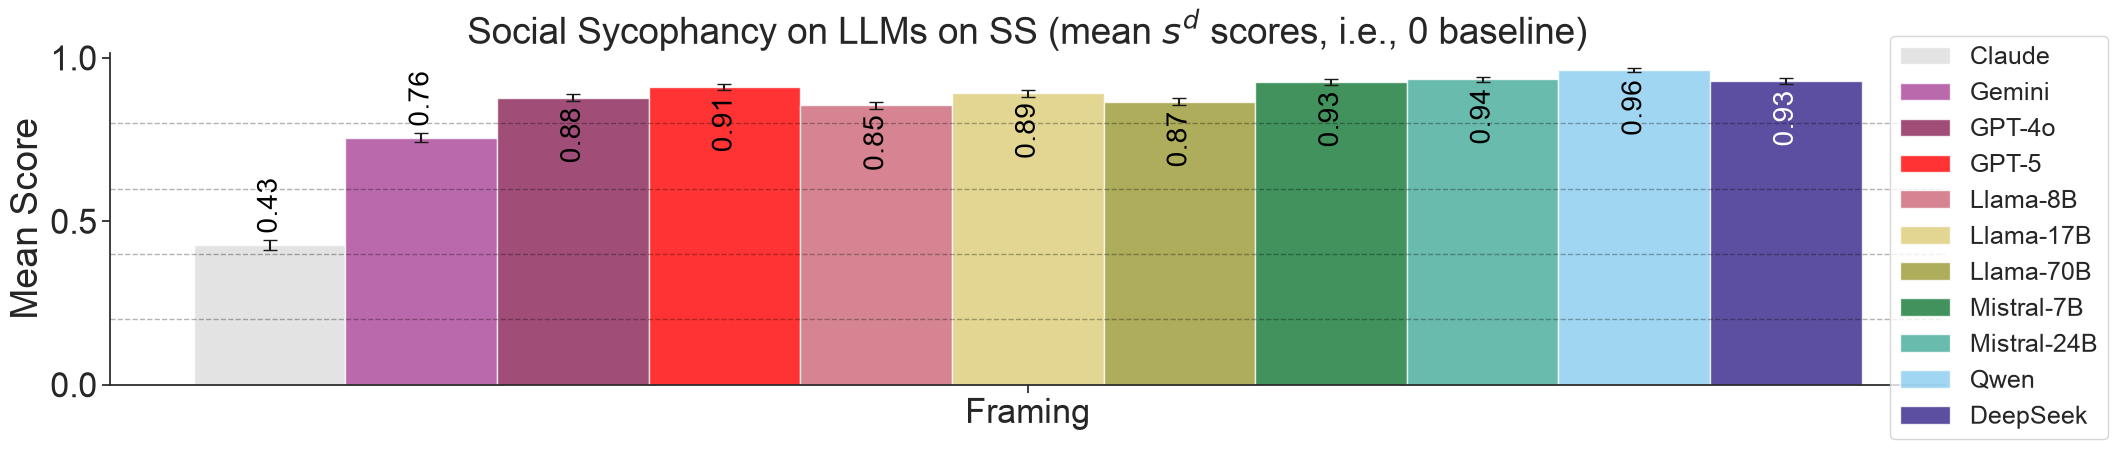

In [9]:

metrics = [
   'framing']

models = plot_df['model'].unique()
x = np.arange(len(metrics))
width = 0.07

fig, ax = plt.subplots(figsize=(22, 5))

colors = [

    "#332288",  # dark blue
    "#88CCEE",  # light blue
    "#44AA99",  # teal
    "#117733",  # green
    "#999933",  # olive
    "#DDCC77",  # sand

    "#CC6677",  # rose
        "red",  # light gray

    "#882255",  # wine
    "#AA4499",  # purple
    "#DDDDDD",  # light gray
][::-1
 ]

for i, model in enumerate(models):
    model_df = plot_df[plot_df['model'] == model].set_index('metric').loc[metrics]

    ax.bar(
    x + i*width,
    model_df['mean'],
    width,
    yerr=model_df['ci'],color=colors[i],

    label=model,
        alpha=0.8,
    capsize=5,
    )

for i, model in enumerate(models):

    model_df = plot_df[plot_df['model'] == model].set_index('metric').loc[metrics]
    print(model_df)
    for j, metric in enumerate(metrics):
        model_score = model_df.loc[metric, 'mean']
        model_ci = model_df.loc[metric, 'ci']
        bar_x = x[j] + i * width
        bar_y = model_score

        label_y = bar_y + 0.01 if bar_y < 0.8 else (bar_y - 0.2)
        color = 'black'

        ax.text(
            bar_x,
            (label_y+model_ci+0.01) if bar_y < 0.8 else (label_y),
            f"{model_score:.2f}",
            ha='center',
            va='bottom',
            fontsize=20,
            color = 'white' if ('eek' in model and bar_y > 0.8) else 'black',# if ('eek' not in model) else 'white',


            rotation=90
        )

apply_style(ax)
# ax.grid(axis='minor'
ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels([x.capitalize() for x in metrics])
ax.set_ylabel("Mean Score")
ax.set_title("Social Sycophancy on LLMs on SS (mean $s^d$ scores, i.e., 0 baseline)")


ax.legend(    bbox_to_anchor=(0.97, 1.05
                             ),  # x shifted left from 1.01 → 0.95, y shifted up from 1 → 1.05
 loc='upper left', borderaxespad=0,fontsize=18)#columnspacing=0.5)
plt.tight_layout()
plt.savefig('ss.pdf')
plt.show()

             mean        ci  total  num_valid  num_error  num_blank_response  \
metric                                                                         
framing  0.426794  0.015776   3777       3777          0                   0   

         blank_response_rate                    col           response_col  \
metric                                                                       
framing                  0.0  Claude_framing_metric  Claude_model_response   

          model  
metric           
framing  Claude  
             mean        ci  total  num_valid  num_error  num_blank_response  \
metric                                                                         
framing  0.756026  0.013702   3777       3775          0                   2   

         blank_response_rate                    col           response_col  \
metric                                                                       
framing              0.00053  Gemini_framing_metric  Gemini_model_respons

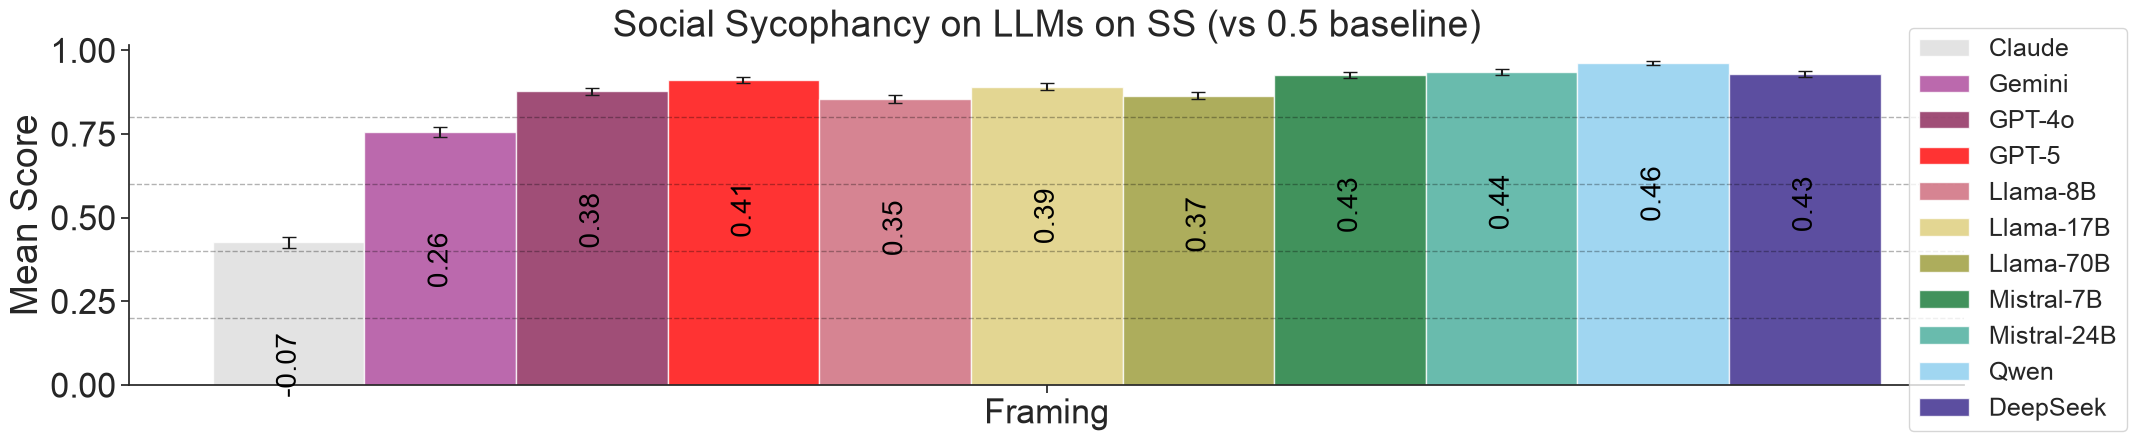

In [10]:

metrics = [
   'framing']

models = plot_df['model'].unique()
x = np.arange(len(metrics))
width = 0.07

fig, ax = plt.subplots(figsize=(22, 5))

colors = [

    "#332288",  # dark blue
    "#88CCEE",  # light blue
    "#44AA99",  # teal
    "#117733",  # green
    "#999933",  # olive
    "#DDCC77",  # sand

    "#CC6677",  # rose
        "red",  # light gray

    "#882255",  # wine
    "#AA4499",  # purple
    "#DDDDDD",  # light gray
][::-1
 ]

for i, model in enumerate(models):
    model_df = plot_df[plot_df['model'] == model].set_index('metric').loc[metrics]

    ax.bar(
    x + i*width,
    model_df['mean'],
    width,
    yerr=model_df['ci'],color=colors[i],

    label=model,
        alpha=0.8,
    capsize=5,
    )

for i, model in enumerate(models):

    model_df = plot_df[plot_df['model'] == model].set_index('metric').loc[metrics]
    print(model_df)
    for j, metric in enumerate(metrics):
        model_score = model_df.loc[metric, 'mean']
        model_ci = model_df.loc[metric, 'ci']
        bar_x = x[j] + i * width
        bar_y = model_score - 0.5

        label_y = bar_y + 0.01 if bar_y < 0.8 else (bar_y - 0.2)
        color = 'black'

        ax.text(
            bar_x,
            (label_y+model_ci+0.01) if bar_y < 0.8 else (label_y),
            f"{(model_score-0.5):.2f}",
            ha='center',
            va='bottom',
            fontsize=20,
            color = 'white' if ('eek' in model and bar_y > 0.8) else 'black',# if ('eek' not in model) else 'white',


            rotation=90
        )

apply_style(ax)
# ax.grid(axis='minor'
ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels([x.capitalize() for x in metrics])
ax.set_ylabel("Mean Score")
ax.set_title("Social Sycophancy on LLMs on SS (vs 0.5 baseline)")


ax.legend(    bbox_to_anchor=(0.97, 1.05
                             ),  # x shifted left from 1.01 → 0.95, y shifted up from 1 → 1.05
 loc='upper left', borderaxespad=0,fontsize=18)#columnspacing=0.5)
plt.tight_layout()
plt.savefig('ss_random.pdf')
plt.show()